# Feature Selection

Pipeline:
1. Load preprocessed data (standard-scaled, OHE applied)
2. Train/test split — test set is locked away immediately
3. **Pearson filter** — remove numeric features with near-zero linear correlation
4. **RF importance filter** — remove features with low tree-based importance
5. Save final feature sets for model training

> Note: Permutation importance is skipped here as a selection step — it will be used post-training as a diagnostic tool. See model evaluation notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

RANDOM_SEED = 42
TARGET      = "Paddy yield(in Kg)"
DROP_COLS   = [TARGET, "Trash(in bundles)", "Hectares "]  

## 1. Load Data

In [2]:
df = pd.read_csv("C:\\dev\\Paddy_Prediction\\data\\transformed\\paddy_preprocessed_tree.csv")

X = df.drop(columns=DROP_COLS)
y = df[TARGET]

print(f"Dataset shape : {df.shape}")
print(f"Features      : {X.shape[1]}")
print(f"Target range  : {y.min():.0f} – {y.max():.0f} kg")

Dataset shape : (2789, 64)
Features      : 61
Target range  : 5410 – 38814 kg


## 2. Train / Test Split

Test set is locked away here and **never used** in any selection step.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f"Train : {X_train.shape[0]} rows")
print(f"Test  : {X_test.shape[0]} rows")

Train : 2231 rows
Test  : 558 rows


OHE (one-hot encoded) columns are binary (0/1). Pearson correlation is not meaningful for them, so they bypass the Pearson filter and are added back afterwards.

In [4]:
def detect_ohe_columns(X: pd.DataFrame) -> list:
    """
    Identify binary (0/1) columns, which are assumed to be one-hot encoded.

    Args:
        X: feature DataFrame

    Returns:
        List of column names that are binary
    """
    return [
        col for col in X.columns
        if set(X[col].dropna().unique()).issubset({0, 1})
    ]

ohe_cols = detect_ohe_columns(X_train)
print(f"OHE columns detected ({len(ohe_cols)}): {ohe_cols}")

OHE columns detected (27): ['Agriblock_Cuddalore', 'Agriblock_Kallakurichi', 'Agriblock_Kurinjipadi', 'Agriblock_Panruti', 'Agriblock_Sankarapuram', 'Variety_delux ponni', 'Variety_ponmani', 'Soil Types_clay', 'Nursery_wet', 'Wind Direction_D1_D30_ENE', 'Wind Direction_D1_D30_NW', 'Wind Direction_D1_D30_SSE', 'Wind Direction_D1_D30_SW', 'Wind Direction_D1_D30_W', 'Wind Direction_D31_D60_NE', 'Wind Direction_D31_D60_S', 'Wind Direction_D31_D60_W', 'Wind Direction_D31_D60_WNW', 'Wind Direction_D61_D90_NNE', 'Wind Direction_D61_D90_NNW', 'Wind Direction_D61_D90_SE', 'Wind Direction_D61_D90_SW', 'Wind Direction_D91_D120_NW', 'Wind Direction_D91_D120_S', 'Wind Direction_D91_D120_SSE', 'Wind Direction_D91_D120_W', 'Wind Direction_D91_D120_WSW']


Pearson Filter Stage

Removes numeric features with absolute Pearson correlation below the threshold.
OHE columns are excluded from this step and added back after.

In [5]:
PEARSON_THRESHOLD = 0.01


def pearson_filter(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    threshold: float = 0.01
) -> tuple:
    """
    Select numeric features by absolute Pearson correlation with target.
    OHE columns are automatically excluded from this filter.

    Args:
        X_train   : training features
        y_train   : training target
        threshold : minimum absolute correlation to keep a feature

    Returns:
        selected_cols : list of selected numeric feature names
        corr_series   : full correlation series (sorted descending)
    """
    ohe_cols       = detect_ohe_columns(X_train)
    candidate_cols = [c for c in X_train.columns if c not in ohe_cols]

    correlations = {}
    for col in candidate_cols:
        if X_train[col].nunique() <= 1:
            continue
        corr, _ = pearsonr(X_train[col], y_train)
        correlations[col] = abs(corr)

    corr_series   = pd.Series(correlations).sort_values(ascending=False)
    selected_cols = corr_series[corr_series >= threshold].index.tolist()

    print(f"Pearson filter: {len(candidate_cols)} numeric → {len(selected_cols)} selected  (threshold={threshold})")
    return selected_cols, corr_series


pearson_cols, pearson_corr = pearson_filter(X_train, y_train, threshold=PEARSON_THRESHOLD)

final_pearson_cols = pearson_cols + ohe_cols
X_train_pearson    = X_train[final_pearson_cols]
X_test_pearson     = X_test[final_pearson_cols]

print(f"Total after adding OHE back: {len(final_pearson_cols)} features")

Pearson filter: 34 numeric → 28 selected  (threshold=0.01)
Total after adding OHE back: 55 features


In [6]:
final_pearson_cols

['LP_nurseryarea(in Tonnes)',
 'Weed28D_thiobencarb',
 'Potassh_50Days',
 'Urea_40Days',
 'Seedrate(in Kg)',
 'LP_Mainfield(in Tonnes)',
 'Nursery area (Cents)',
 'Pest_60Day(in ml)',
 'Micronutrients_70Days',
 'DAP_20days',
 'Inst Wind Speed_D61_D90(in Knots)',
 'Inst Wind Speed_D1_D30(in Knots)',
 'Relative Humidity_D1_D30',
 'Min temp_D1_D30',
 'Min temp_D61_D90',
 '51_70AI(in mm)',
 '51_70DRain(in mm)',
 'Max temp_D61_D90',
 'Max temp_D91_D120',
 'Max temp_D1_D30',
 'Max temp_D31_D60',
 '30_50DAI(in mm)',
 '71_105DAI(in mm)',
 '30_50DRain( in mm)',
 '71_105DRain(in mm)',
 'Min temp_D31_D60',
 'Inst Wind Speed_D91_D120(in Knots)',
 'Inst Wind Speed_D31_D60(in Knots)',
 'Agriblock_Cuddalore',
 'Agriblock_Kallakurichi',
 'Agriblock_Kurinjipadi',
 'Agriblock_Panruti',
 'Agriblock_Sankarapuram',
 'Variety_delux ponni',
 'Variety_ponmani',
 'Soil Types_clay',
 'Nursery_wet',
 'Wind Direction_D1_D30_ENE',
 'Wind Direction_D1_D30_NW',
 'Wind Direction_D1_D30_SSE',
 'Wind Direction_D1_D30_S

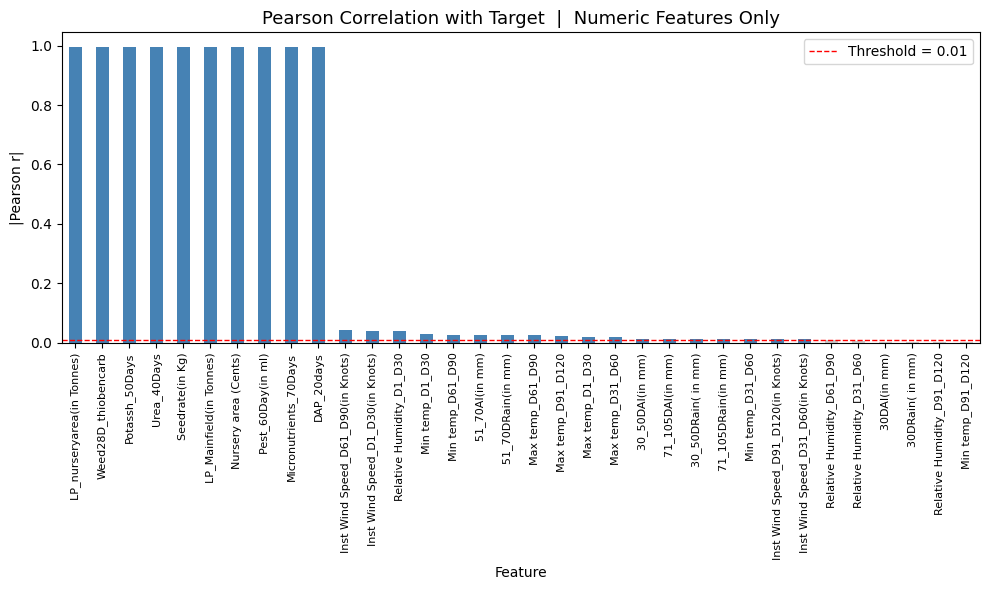

In [8]:

fig, ax = plt.subplots(figsize=(10, 6))

colors = ["steelblue" if v >= PEARSON_THRESHOLD else "#cccccc" for v in pearson_corr]
pearson_corr.plot(kind="bar", color=colors, ax=ax)

ax.axhline(PEARSON_THRESHOLD, color="red", linestyle="--", linewidth=1, label=f"Threshold = {PEARSON_THRESHOLD}")
ax.set_title("Pearson Correlation with Target  |  Numeric Features Only", fontsize=13)
ax.set_ylabel("|Pearson r|")
ax.set_xlabel("Feature")
ax.legend()
ax.tick_params(axis="x", labelsize=8)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## 5. Random Forest Importance Filter

Trained on the Pearson-filtered training set. Features below the importance threshold are dropped.

In [9]:
RF_IMPORTANCE_THRESHOLD = 0.01


def rf_importance_filter(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    threshold: float = 0.005
) -> tuple:
    """
    Select features using Random Forest mean-decrease-in-impurity (MDI) importance.

    Args:
        X_train   : training features (post-Pearson)
        y_train   : training target
        threshold : minimum importance score to retain a feature

    Returns:
        rf_model      : fitted RandomForestRegressor
        selected_cols : list of selected feature names
        importances   : full importance series (sorted descending)
    """
    rf_model = RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)

    importances   = pd.Series(rf_model.feature_importances_, index=X_train.columns)
    importances   = importances.sort_values(ascending=False)
    selected_cols = importances[importances >= threshold].index.tolist()

    print(f"RF importance filter: {len(X_train.columns)} → {len(selected_cols)} features  (threshold={threshold})")
    return rf_model, selected_cols, importances


rf_model, rf_cols, rf_importances = rf_importance_filter(
    X_train_pearson, y_train, threshold=RF_IMPORTANCE_THRESHOLD
)

RF importance filter: 55 → 10 features  (threshold=0.01)


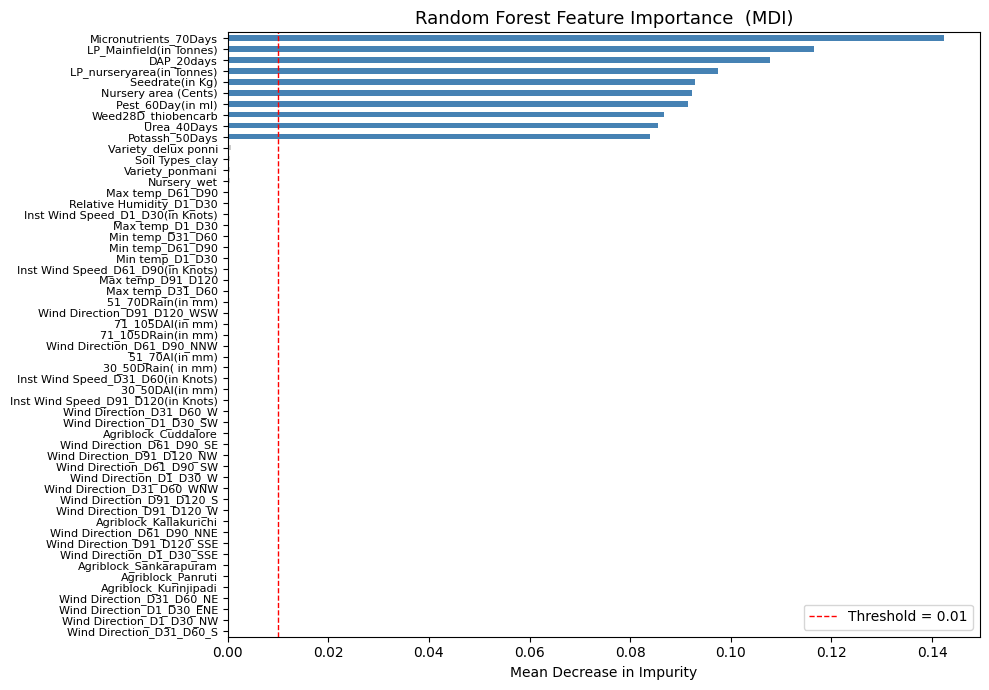

In [12]:
# --- Visualise RF importances ---

fig, ax = plt.subplots(figsize=(10, 7))

colors = ["steelblue" if v >= RF_IMPORTANCE_THRESHOLD else "#cccccc" for v in rf_importances]
rf_importances.plot(kind="barh", color=colors, ax=ax)

ax.axvline(RF_IMPORTANCE_THRESHOLD, color="red", linestyle="--", linewidth=1, label=f"Threshold = {RF_IMPORTANCE_THRESHOLD}")
ax.invert_yaxis()
ax.set_title("Random Forest Feature Importance  (MDI)", fontsize=13)
ax.set_xlabel("Mean Decrease in Impurity")
ax.legend()
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()


## 6. Final Feature Set

In [24]:
X_train_final = X_train_pearson[rf_cols]
X_test_final  = X_test_pearson[rf_cols]

print(f"Final feature count : {len(rf_cols)}")
print(f"Train shape         : {X_train_final.shape}")
print(f"Test shape          : {X_test_final.shape}")
print(f"\nSelected features:\n{rf_cols}")

Final feature count : 10
Train shape         : (2231, 10)
Test shape          : (558, 10)

Selected features:
['Micronutrients_70Days', 'LP_Mainfield(in Tonnes)', 'DAP_20days', 'LP_nurseryarea(in Tonnes)', 'Seedrate(in Kg)', 'Nursery area (Cents)', 'Pest_60Day(in ml)', 'Weed28D_thiobencarb', 'Urea_40Days', 'Potassh_50Days']


Random Forest feature importance identified key agronomic inputs such as micronutrients, DAP application, seed rate, and nursery characteristics as important predictors due to their frequent usage in tree-based splits. However, SHAP analysis provided a more nuanced understanding of feature influence by quantifying their contribution to individual predictions.

The SHAP summary plot revealed that rainfall at different growth stages and potassium application had the most significant impact on yield prediction. In particular, mid-stage rainfall (30–50 days) and potassium levels exhibited strong positive contributions, while certain irrigation features showed negative effects.

## 7. Save Outputs

In [25]:
import os
os.makedirs("../data/final", exist_ok=True)

X_train_final.to_csv("../data/final/X_train.csv", index=False)
X_test_final.to_csv("../data/final/X_test.csv",  index=False)
y_train.to_csv("../data/final/y_train.csv",       index=False)
y_test.to_csv("../data/final/y_test.csv",         index=False)

print("Saved to data/final/")
print("  X_train.csv  X_test.csv  y_train.csv  y_test.csv")

Saved to data/final/
  X_train.csv  X_test.csv  y_train.csv  y_test.csv


In [26]:
X_train_final

,Micronutrients_70Days,LP_Mainfield(in Tonnes),DAP_20days,LP_nurseryarea(in Tonnes),Seedrate(in Kg),Nursery area (Cents),Pest_60Day(in ml),Weed28D_thiobencarb,Urea_40Days,Potassh_50Days
599,75.0,0.892189,200.0,5.0,125.0,100.0,3000.0,10.0,0.892189,0.892189
1378,60.0,0.196546,160.0,4.0,100.0,80.0,2400.0,8.0,0.196546,0.196546
1717,45.0,-0.499097,120.0,3.0,75.0,60.0,1800.0,6.0,-0.499097,-0.499097
100,90.0,1.587832,240.0,6.0,150.0,120.0,3600.0,12.0,1.587832,1.587832
315,75.0,0.892189,200.0,5.0,125.0,100.0,3000.0,10.0,0.892189,0.892189
...,...,...,...,...,...,...,...,...,...,...
1638,60.0,0.196546,160.0,4.0,100.0,80.0,2400.0,8.0,0.196546,0.196546
1095,60.0,0.196546,160.0,4.0,100.0,80.0,2400.0,8.0,0.196546,0.196546
1130,60.0,0.196546,160.0,4.0,100.0,80.0,2400.0,8.0,0.196546,0.196546
1294,60.0,0.196546,160.0,4.0,100.0,80.0,2400.0,8.0,0.196546,0.196546


In [28]:
## for traditional models

# Load the scaled version of the full dataset
df_scaled = pd.read_csv(r"C:\dev\Paddy_Prediction\data\transformed\paddy_preprocessed.csv")

# Extract only the 11 selected feature columns + target
X_scaled = df_scaled[rf_cols]  # same 11 column names
y = df_scaled[TARGET]

# Same split with same random seed — guarantees identical rows
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Save
X_train_scaled.to_csv("../../data/final/X_train_scaled.csv", index=False)
X_test_scaled.to_csv("../../data/final/X_test_scaled.csv", index=False)